# Novae + scConcept

One of Novae’s key strengths is its ability to operate across datasets with different gene panel sizes. In the original model, this is achieved by projecting the gene expression vector through a learnable gene-embedding matrix. More recently, we introduced a new variant that replaces this projection step with a per-cell embedding generated by [scConcept](https://scconcept.readthedocs.io/en/latest/) embedding.

> ℹ️ [scConcept](https://scconcept.readthedocs.io/en/latest/) is a contrastive learning model that produces robust single-cell embeddings and is particularly well suited to spatial transcriptomics datasets with heterogeneous gene panels. This makes it a natural complement to Novae.

✅ We recommend using this newer Novae variant whenever possible. It consistently outperforms the original model, with the largest gains observed in **zero-shot settings**.


In [1]:
import novae

## Compute the scConcept embeddings

First, you'll need to compute the scConcept embeddings for each cell of your dataset.
For that, refer to their [official documentation](https://scconcept.readthedocs.io/en/latest/).

⚠️ Make sure to use the `corpus360M[multi-species]-model170M` scConcept model, since it is the one we used to train Novae.

> We recommend doing that in a separate environment than Novae. Once you get the scConcept embeddings, you'll not need the `sc_concept` dependency anymore, and you can switch back to an environment with `novae`.


In [ ]:
### We recommend doing that in a separate environment than Novae.
# Once you get the scConcept embeddings, you'll not need the `sc_concept`
# dependency anymore, and you can switch back to an environment with `novae`.

from concept import scConcept

adata = ...  # one of your datasets as an AnnData object

concept = scConcept(cache_dir="./cache/")
concept.load_config_and_model(model_name="corpus360M[multi-species]-model170M")

adata.var["gene_id"] = concept.map_gene_names_to_ids(species="hsapiens", gene_names=adata.var_names.tolist())

result = concept.extract_embeddings(adata=adata, gene_id_column="gene_id")
adata.obsm["X_scConcept"] = result["cls_cell_emb"]  # you need to store the embeddings here

For the sake of this tutorial, we'll load a slide with pre-computed scConcept embeddings:


In [2]:
adata = novae.load_dataset(
    pattern="Xenium_Prime_Breast_Cancer_FFPE_outs",
    embeddings="corpus360M[multi-species]-model170M",
)[0]

[INFO] (novae.data._load.hf) Found 1 h5ad file(s) matching the filters.


We see `"X_scConcept"` in the `obsm`:


In [3]:
adata

AnnData object with n_obs × n_vars = 699110 × 5101
    obs: 'cell_id', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'novae_sid', 'name'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'log1p'
    obsm: 'counts', 'spatial', 'X_scConcept'

## Zero-shot inference

### Spatial neighbors

First, as usual, we create the graph of neighbors. Here, we use `radius=100` microns because the tissue is relatively sparse.


In [4]:
novae.spatial_neighbors(adata, radius=100)

[INFO] (novae.utils.build) Computing graph on 699,110 cells (coord_type=generic, delaunay=True, radius=[0.0, 100.0], n_neighs=None)


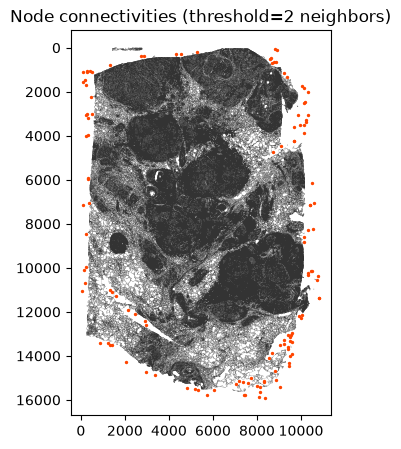

In [5]:
novae.plot.connectivities(adata)

### Computing representations


In [8]:
model = novae.Novae.from_pretrained("prism-oncology/novae-scConcept-multi-species")

model

╭─ Novae ──────────────────────────────────────────────────╮
│ Embedding name: X_scConcept                              │
│ Parameters: 3.1M                                         │
│ Model name: prism-oncology/novae-scConcept-multi-species │
│ Trained: True                                            │
│ Multimodal: False                                        │
╰──────────────────────────────────────────────────────────╯

In [7]:
model.compute_representations(adata, zero_shot=True, accelerator="gpu", num_workers=4)

Computing representations:   0%|          | 0/2731 [00:00<?, ?it/s]

[INFO] (novae.model) Updating the prototypes using reference='all' and assigning each cell to a leaf.


### Assigning domains


As recommended in zero-shot, we use a `resolution` instead of a `level` when assigning the domains:


In [8]:
model.assign_domains(adata, resolution=1)

'novae_domains_res1'

And, finally, we plot the domains:


[INFO] (novae.utils._validate) Using obs_key='novae_domains_res1' by default.


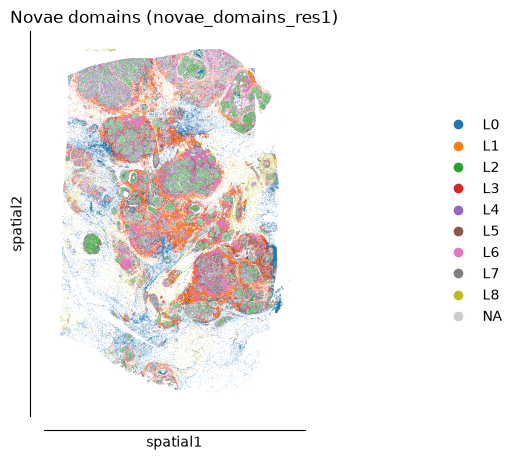

In [9]:
novae.plot.domains(adata)

### Domains labeling

In addition, we run the automated domains labeling from [this tutorial](../labeling).


In [10]:
import dotenv

dotenv.load_dotenv("./.env")

True

In [11]:
df_labels = novae.label_domains(adata, tissue="breast-cancer", species="human")

[INFO] (novae.utils._validate) Using obs_key='novae_domains_res1' by default.


In [12]:
adata.obs["novae_domains_labeled"] = adata.obs["novae_domains_res1"].map(df_labels["label"])

This gives the following labels, to be carefully checked by a biologist (see more details about validation, also in [this tutorial](../labeling)).


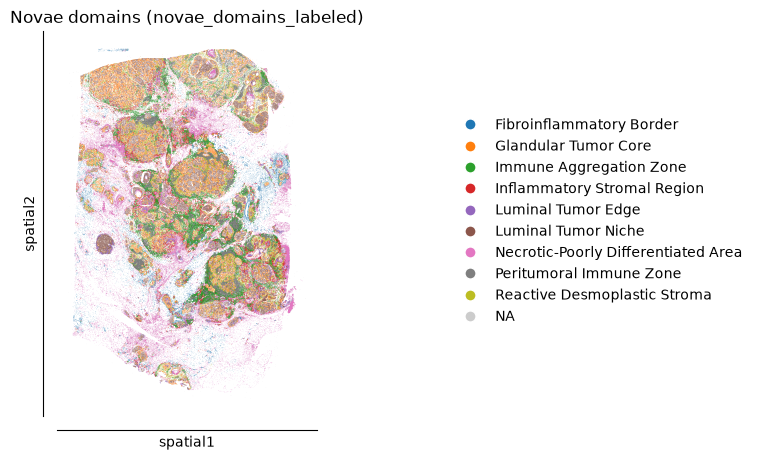

In [13]:
novae.plot.domains(adata, obs_key="novae_domains_labeled")

### Fine-tuning

As for every other Novae model, we can also [fine-tune](../../api/Novae/#novae.Novae.fine_tune) the model, which should improve results compared to the zero-shot mode.

> See fine-tuning advice [here](../../advice/#fine-tuning).


In [ ]:
model.fine_tune(adata, accelerator="gpu", num_workers=4)

model.compute_representations(adata, accelerator="gpu", num_workers=4)
model.assign_domains(adata, resolution=1)

[INFO] (novae.utils._validate) Using obs_key='novae_domains_res1' by default.


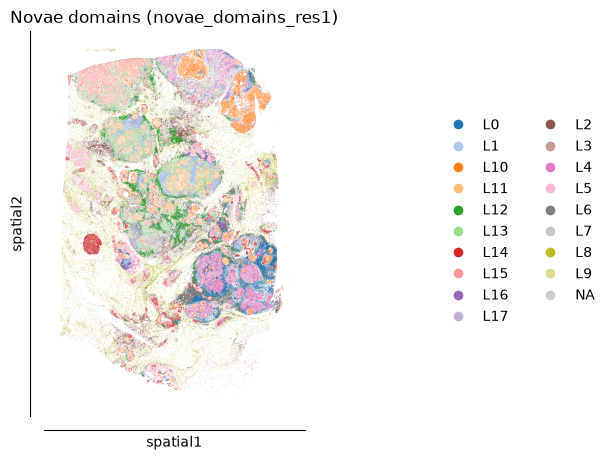

In [10]:
novae.plot.domains(adata)

## Multi-slides

Using Novae on multiple slides is very similar. The only difference is that we'll need to choose the slides on which we run the zero-shot, since these slides are used to re-adjust the prototypes.

To show that, we load three CRC slides (notice the `.*` in the `pattern` argument):


In [2]:
adatas = res = novae.load_dataset(
    pattern="Xenium_V1_Human_Colon_Cancer_P.*_CRC_Add_on_FFPE_outs",
    embeddings="corpus360M[multi-species]-model170M",
)

[INFO] (novae.data._load.hf) Found 3 h5ad file(s) matching the filters.


Here we provide `slide_key="name"`, where `"name"` is the column of `adata.obs` containing the slide names. It's optional (since we have already a list of `AnnData`), but useful to keep the slide name in the plots below.


In [3]:
novae.spatial_neighbors(adatas, radius=80, slide_key="name")

[INFO] (novae.utils.build) Computing graph on 307,762 cells (coord_type=generic, delaunay=True, radius=[0.0, 80.0], n_neighs=None)
[INFO] (novae.utils.build) Computing graph on 340,837 cells (coord_type=generic, delaunay=True, radius=[0.0, 80.0], n_neighs=None)
[INFO] (novae.utils.build) Computing graph on 275,998 cells (coord_type=generic, delaunay=True, radius=[0.0, 80.0], n_neighs=None)


Then, just run the `zero_shot` as usual (notice that it handles a `list[AnnData]` as an input), but be careful of which `reference` you use. Indeed, running the zero-shot mode updates the prototypes under the hood based on a given reference(s) slide(s), see more details [here](../../advice/#using-references).

> ℹ️ Once zero-shot inference is complete, the model functions exactly like a fully trained model.


In [6]:
model = novae.Novae.from_pretrained("prism-oncology/novae-scConcept-multi-species")

model.compute_representations(
    adatas,
    zero_shot=True,
    reference="largest",  # check more options in the docs
    accelerator="gpu",
    num_workers=4,
)

Computing representations:   0%|          | 0/1203 [00:00<?, ?it/s]

Computing representations:   0%|          | 0/1332 [00:00<?, ?it/s]

Computing representations:   0%|          | 0/1078 [00:00<?, ?it/s]

[INFO] (novae.model) Updating the prototypes using reference='largest' and assigning each cell to a leaf.


In [7]:
model.assign_domains(adatas, resolution=1)

'novae_domains_res1'

[INFO] (novae.utils._validate) Using obs_key='novae_domains_res1' by default.


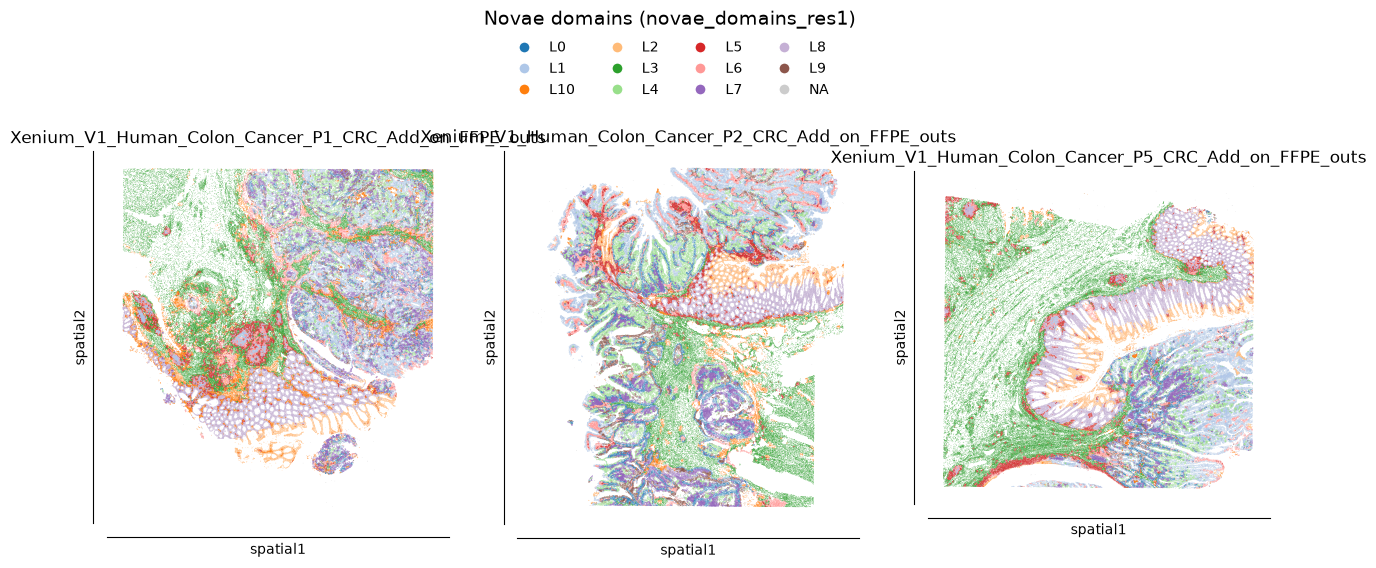

In [8]:
novae.plot.domains(adatas)

### Notes

Running `compute_representations` with `zero_shot=True` is equivalent to:

1. Running `compute_representations` with `zero_shot=False`.
2. And then adjusting the prototypes with `model.assign_to_kmeans_prototypes(adatas, reference)`


### Continuous data generation

If you are continuously generating new spatial slides, you will likely want to save your model and reuse it for future datasets. You can save the model, reload it, and assign the existing domains to new slides — allowing you to preserve the prototypes obtained during your zero-shot inference!


In [9]:
model.save_pretrained("local_model_path")

model_reloaded = novae.Novae.from_pretrained("local_model_path")

Loading weights from local directory


For the sake of the tutorial, we re-run the model on one of the three slides, but you can do that on any new slide.

> Note that, here, we don't provide `zero_shot=True`, else it will update the prototypes again.


In [ ]:
new_adata = adatas[-1]  # we fake a 'new slide', but use new slide(s) for real-world usage

model_reloaded.compute_representations(new_adata, accelerator="gpu", num_workers=4)

Computing representations:   0%|          | 0/1078 [00:00<?, ?it/s]

We use the same resolution as before:


In [12]:
model_reloaded.assign_domains(new_adata, resolution=1)

'novae_domains_res1'

And we recover the domains we had before:


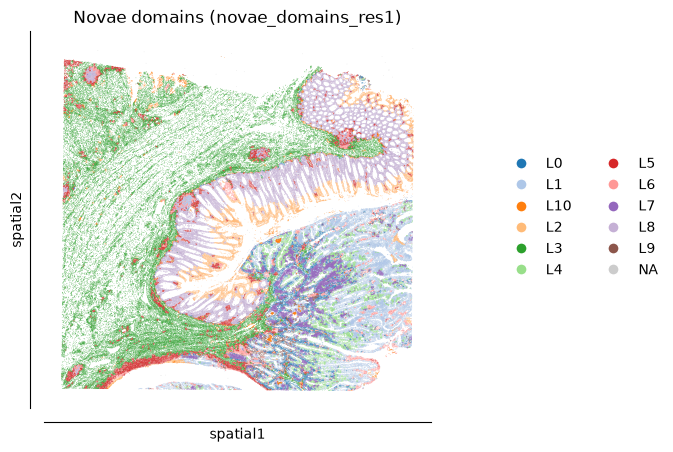

In [13]:
novae.plot.domains(new_adata, obs_key="novae_domains_res1")